In [25]:
import sys
sys.path.append('../')

import numpy as np
from matplotlib import pyplot as plt
from qutip.qip.operations import rz, cz_gate
import cmath
from tqdm import tqdm
from matplotlib.colors import LogNorm
import datetime
import pytz
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
from joblib import Parallel, delayed
import itertools
import scipy.sparse as ssp
from sympy import symbols
import utils_2Q_gate_zp as ut
ut.set_fig_font() ### Set various sizes in plotting
from brokenaxes import brokenaxes
from qutip.qip.operations import rz, cz_gate, cnot, rx, hadamard_transform, swap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import qutip as qt
import scqubits as scq
import pandas as pd

SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

EL        = 0.377 # GHz
EJ        = 6.013 # Soft Zero Pi (Gyenis)
EC_phi    = 1.142
EC_theta  = 0.092
E_CJ = 2 * EC_phi
E_C = 2./(1./EC_theta -1./EC_phi)

colors = [
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#d62728",  # Red
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Yellow-green
    "#17becf",  # Cyan
]

## Prepare two zero pi 

In [ ]:
args_all = ut.get_operator_two_zeropi()

In [27]:
[n_theta1, n_theta2, n_theta1_dress, n_theta2_dress, n_theta1_truc, n_theta2_truc,
eval_tot, order_sort, H0, trunc_states, eket0, eket1, eket_tot  ] = args_all
truc = len(trunc_states)
state_tot = [qt.basis(truc, i) for i in range(truc)]
W_20_50 = np.abs(ut.transition_frequency(order_sort.index('20') , order_sort.index('50'), eval_tot))

drive_ab = False
drive_term = n_theta2_truc + n_theta1_truc if drive_ab else n_theta2_truc
H_qbt_drive = [H0, [2*np.pi* drive_term, ut.drive_gauss_A] ]
logi_space = ['00', '02', '20', '22']


In [28]:
for i in range(4):
    idx = order_sort.index(logi_space[i])
    print(i, logi_space[i], eval_tot[idx])

0 00 0.0
1 02 3.4346933439254776
2 20 3.468609755856003
3 22 6.903302831364228


In [29]:
i = order_sort.index('02')
eval_tot[i]


3.4346933439254776

In [30]:
index_transition = []
w_transition = []
na_list = []
nb_list = []
for state_i in logi_space:
    for j in np.arange(0, len(eval_tot)):
        index_transition.append(f'{state_i}-{order_sort[j]}')
        w_transition.append( 2*np.pi*( np.abs( eval_tot[order_sort.index(state_i)] - eval_tot[j] )))
        na_list.append(np.abs(n_theta1_dress[order_sort.index(state_i) ,j]))
        nb_list.append(np.abs(n_theta2_dress[order_sort.index(state_i) ,j]))
sorted_indices = np.argsort(w_transition)
w_transition = sorted(w_transition)
index_transition = [index_transition[i] for i in sorted_indices]
na_list = [na_list[i] for i in sorted_indices]
nb_list = [nb_list[i] for i in sorted_indices]

print('Trans' + ' ;  w_ij' + ';     na' +  ';      nb' + ';      na+nb')
thresh = 0.01
trans = []
w_ij = []
N_theta1 = []
N_theta2 = []
for i in range(len(w_transition)):
    if na_list[i] > thresh or nb_list[i] > thresh:
        print( index_transition[i],';  %.3f'%w_transition[i], ';  %.3f'%na_list[i],
                ';  %.3f'%nb_list[i], ';  %.3f'%(na_list[i]+nb_list[i]))
        trans.append(index_transition[i])
        w_ij.append(np.round(w_transition[i], 3))
        N_theta1.append(na_list[i])
        N_theta2.append(nb_list[i])


Trans ;  w_ij;     na;      nb;      na+nb
22-12 ;  5.521 ;  0.010 ;  0.001 ;  0.011
02-01 ;  6.442 ;  0.001 ;  0.018 ;  0.019
22-21 ;  6.487 ;  0.001 ;  0.017 ;  0.018
22-25 ;  14.676 ;  0.386 ;  1.239 ;  1.625
02-05 ;  14.697 ;  0.312 ;  1.258 ;  1.570
20-21 ;  15.093 ;  0.576 ;  1.196 ;  1.772
00-01 ;  15.139 ;  0.434 ;  1.252 ;  1.686
22-52 ;  15.922 ;  1.278 ;  0.344 ;  1.622
20-50 ;  15.984 ;  1.204 ;  0.541 ;  1.744
02-12 ;  16.273 ;  1.316 ;  0.268 ;  1.585
00-10 ;  16.309 ;  1.281 ;  0.394 ;  1.675
22-28 ;  21.267 ;  0.006 ;  0.116 ;  0.122
02-08 ;  21.280 ;  0.007 ;  0.117 ;  0.124
22-91 ;  23.330 ;  0.001 ;  0.015 ;  0.016
20-80 ;  23.606 ;  0.042 ;  0.001 ;  0.044
22-82 ;  23.770 ;  0.059 ;  0.002 ;  0.060
02-80 ;  23.819 ;  0.000 ;  0.010 ;  0.011
20-14 ;  24.111 ;  0.047 ;  0.001 ;  0.048
22-45 ;  24.977 ;  0.029 ;  0.001 ;  0.030
20-41 ;  25.528 ;  0.017 ;  0.000 ;  0.018
20-28 ;  42.848 ;  0.000 ;  0.045 ;  0.045
00-08 ;  42.861 ;  0.000 ;  0.045 ;  0.045
00-80 ;  45.40

# Fig 1

In [31]:
phi_grid = scq.Grid1d(-6*np.pi, 6*np.pi, 100)
zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=0.1,
                        ng=0., flux=0., ncut=30)
def V(theta, phi):
    phiext = 0.
    return (-2*EJ * np.cos(theta) * np.cos(phi - np.pi * phiext) + EL* phi**2 + 2*EJ)

In [32]:
E_fig4a = np.array([0.        , 2.50274223, 3.38939671, 3.47166362, 4.85191956,
       5.78427788, 5.89396709, 6.89031079, 7.7952468 , 8.06032907])
E_fig2 = np.array([0.        , 2.52873069, 3.27944761, 3.43749328, 4.78088146,
       5.68964405, 5.8081783 , 6.87498656, 7.78374915, 8.09984049])

In [33]:
# phi_flat = phi.ravel()
# theta_flat = theta.ravel()
# V_flat = V(theta, phi).ravel()
# fig = plt.figure(figsize=(5, 5))  # Adjust figure size (width, height)
# ax = fig.add_subplot(111, projection='3d')
# ax.plot_trisurf(phi_flat, theta_flat, V_flat, cmap='viridis')
# ax.set_xlim([-3 * np.pi, 3 * np.pi])
# ax.set_ylim([-0.5 * np.pi, 1.5 * np.pi])
# ax.set_zlim([V(theta, phi).min(), 30])
# ax.set_box_aspect([5, 2, 1])
# ax.view_init(elev=-30, azim=86)
# ax.axis('off')

In [34]:
# fig = plt.figure(figsize=(5,5))
# ax = fig.add_subplot(111, projection='3d')
# ax.plot_surface(phi, theta, V(theta, phi), cmap='viridis', rstride=1, cstride=1, shade=False)

# ax.set_xlim([-3 * np.pi, 3 * np.pi])
# ax.set_ylim([-0.5 * np.pi, 1.5 * np.pi])
# ax.set_zlim([V(theta, phi).min(), 30])
# ax.set_box_aspect([5, 2, 1])
# ax.view_init(elev=-30, azim=86)  # Set the elevation and azimuth of the viewing angle
# ax.axis('off');
# print(V(theta, phi).min(), V(theta, phi).max())

Spectral data:   0%|          | 0/3 [00:00<?, ?it/s]

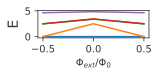

In [35]:
flux_list = np.linspace(-0.5, 0.5, 3)
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, ax = zero_pi.plot_evals_vs_paramvals('flux', flux_list, evals_count=5, subtract_ground=True)
fig.set_size_inches(2, .5)
for i, line in enumerate(ax.get_lines()):
    line.set_color(default_colors[i % len(default_colors)])
for spine in ax.spines.values():
    spine.set_visible(True)
ax.set_xlabel(ax.get_xlabel(), fontsize=10)  # Set font size for X-axis label
ax.set_ylabel('E', fontsize=BIGGER_SIZE)  # Set font size for Y-axis label
ax.tick_params(axis='both', which='major', labelsize=SMALL_SIZE)
# plt.savefig('image/energy_vs_phitxt.pdf', dpi=300, bbox_inches='tight')

lines = ax.get_lines()
x_data = lines[0].get_xdata()
y_data = [line.get_ydata() for line in lines]
data = np.column_stack([x_data] + y_data)
header = 'Flux, E0, E1, E2, E3, E4'
# np.savetxt('eigenvalues_vs_flux.txt', data, header=header, fmt='%f', delimiter=',', comments='')

Spectral data:   0%|          | 0/3 [00:00<?, ?it/s]

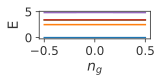

In [36]:
ng_list = np.linspace(-0.5, 0.5, 3)
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, ax = zero_pi.plot_evals_vs_paramvals('ng', ng_list, evals_count=5, subtract_ground=True)
fig.set_size_inches(2, .5)
for i, line in enumerate(ax.get_lines()):
    line.set_color(default_colors[i % len(default_colors)])
for spine in ax.spines.values():
    spine.set_visible(True)
ax.set_xlabel(ax.get_xlabel(), fontsize=BIGGER_SIZE)  # Set font size for X-axis label
ax.set_ylabel('E', fontsize=BIGGER_SIZE)  # Set font size for Y-axis label
ax.tick_params(axis='both', which='major', labelsize=MEDIUM_SIZE)
# plt.savefig('image/energy_vs_ng.pdf', dpi=300, bbox_inches='tight')

lines = ax.get_lines()
x_data = lines[0].get_xdata()
y_data = [line.get_ydata() for line in lines]
data = np.column_stack([x_data] + y_data)
header = 'ng, E0, E1, E2, E3, E4'
# np.savetxt('eigenvalues_vs_ng.txt', data, header=header, fmt='%f', delimiter=',', comments='')


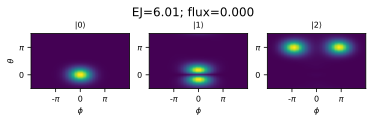

In [37]:
wf = {}
fig, ax = plt.subplots(figsize=(6,1), nrows=1, ncols=3)
fig.suptitle('EJ=%.2f; '%EJ+'flux=%.3f'%zero_pi.flux, fontsize=12, y=1.25)

for i in range(3):
    wf[i] = zero_pi.wavefunction(esys=None, which=i, theta_grid=None)
    [phi_min, theta_min] = wf[i].gridspec.min_vals
    [phi_max, theta_max] = wf[i].gridspec.max_vals
    ax[i].imshow(np.abs(wf[i].amplitudes),extent=[phi_min, phi_max, theta_max, theta_min], aspect="auto")

    ax[i].set_xlim(-2*np.pi,2*np.pi)
    ax[i].set_xticks([-np.pi,0,np.pi],['-$\pi$','0','$\pi$'])
    ax[i].set_xlabel('$\phi$' )

    ax[i].set_yticks([0,np.pi],['0','$\pi$'])
    ax[i].invert_yaxis()
    ax[i].set_title('$|%d\\rangle$'%i )
    # ax[i].grid()
ax[0].set_ylabel('$\\theta$');

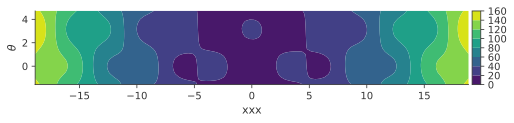

In [38]:
theta_grid = scq.Grid1d(-0.5*np.pi, 1.5*np.pi, 30)
fig, ax = zero_pi.plot_potential(theta_grid=theta_grid)
ax.set_xlabel('xxx')
lines = ax.get_lines()

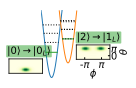

In [39]:

theta_1 = np.linspace(-2, 2, num=50)
theta_2 = np.linspace(1.47, 6.28-1.47, num=50)
eval_zp = np.array([ 6.40836721,  8.91173084,  9.80996825,  9.83378077, 11.24434186,
       12.19997287, 12.2769947 , 13.37183189, 14.19848836, 14.50087939])

## double valley and levels
x_size, y_size = 0.66, 1.33
fig, ax = plt.subplots(figsize=(x_size, y_size))
plt.plot(theta_1, V(theta_1, 0), color=colors[0], linewidth=1)
plt.plot(theta_2, V(theta_2, np.pi), color=colors[1], linewidth=1)
plt.xlim(-2,5)
valley = [0,0,1,1,0, 1,1,0,1,1]
for i, evals in enumerate(eval_zp):
    if valley[i] == 0:
        x0 = -np.arccos(-0.5*evals/EJ+1)
        if i == 0:
            plt.axhline(y=evals, xmin=(x0+2)/7, xmax=(-x0+2)/7, linestyle='-', linewidth=1., color=colors[2])
        else:
            plt.axhline(y=evals, xmin=(x0+2)/7, xmax=(-x0+2)/7, linestyle='dotted', linewidth=1., color='black')

    else:
        x0 = np.arccos(0.5*(evals - EL*np.pi**2 - 2*EJ) / EJ)
        if i == 2:
            plt.axhline(y=evals, xmin=(x0+2)/7, xmax=(2*np.pi-x0+2)/7, linestyle='-', linewidth=1., color=colors[2])
        else:
            plt.axhline(y=evals, xmin=(x0+2)/7, xmax=(2*np.pi-x0+2)/7, linestyle='dotted', linewidth=1., color='black')

## text
ax.text(-8.5, 6, r'$|0\rangle\to|0_L\rangle$', fontsize=SMALL_SIZE, color='black',
        bbox=dict(facecolor=colors[2], edgecolor='none', alpha=0.5, boxstyle="round,pad=0.1"))
ax.text(4.8, 9.5, r'$|2\rangle\to|1_L\rangle$', fontsize=SMALL_SIZE, color='black',
        bbox=dict(facecolor=colors[2], edgecolor='none', alpha=0.5, boxstyle="round,pad=0.1"))
ax.axis('off')

## wavefuction inset
## 0 state
ax1 = inset_axes(ax, width=0.47, height=0.2,
                    bbox_transform=ax.transAxes, # relative axes coordinates
                    bbox_to_anchor=(-0.42, 0.2),    # relative axes coordinates
                    loc='center')
wf = zero_pi.wavefunction(esys=None, which=0, theta_grid=None)
[phi_min, theta_min] = wf.gridspec.min_vals
[phi_max, theta_max] = wf.gridspec.max_vals
ax1.imshow(np.abs(wf.amplitudes), extent=[phi_min, phi_max, theta_max, theta_min], aspect="auto", cmap='YlGn')
ax1.set_xlim(-2*np.pi, 2*np.pi)
ax1.invert_yaxis()
ax1.set_xticks([])  # Remove x-axis ticks
ax1.set_yticks([])  # Remove y-axis ticks

# np.savetxt('data_fig/eigenvector_2.txt', np.abs(wf.amplitudes), delimiter=',')



## 2 state
ax1 = inset_axes(ax, width=0.47, height=0.2,
                    bbox_transform=ax.transAxes, # relative axes coordinates
                    bbox_to_anchor=(1.42, 0.39),    # relative axes coordinates
                    loc='center')
wf = zero_pi.wavefunction(esys=None, which=2, theta_grid=None)
[phi_min, theta_min] = wf.gridspec.min_vals
[phi_max, theta_max] = wf.gridspec.max_vals
ax1.imshow(np.abs(wf.amplitudes), extent=[phi_min, phi_max, theta_max, theta_min], aspect="auto", cmap='YlGn')
ax1.set_xlim(-2*np.pi, 2*np.pi)
ax1.set_xticks([-np.pi, np.pi], ['-$\pi$', '$\pi$'], fontsize=SMALL_SIZE)
ax1.set_xlabel('$\phi$' , fontsize=SMALL_SIZE, labelpad=-1)
ax1.set_yticks([0, np.pi], ['0', '$\pi$'], fontsize=SMALL_SIZE)
ax1.set_ylabel('$\\theta$', fontsize=SMALL_SIZE, labelpad=2)
ax1.yaxis.tick_right()
ax1.yaxis.set_label_position('right')
ax1.tick_params(axis='x', pad=1, direction='in', length=2, width=1)  # Adjust padding for x-axis ticks
ax1.tick_params(axis='y', pad=1, direction='in', length=2, width=1) # Adjust padding for y-axis ticks
ax1.invert_yaxis()



# plt.savefig(f'image/fig1c_double_valley_{x_size}_{y_size}.pdf', dpi=300, bbox_inches='tight')

Text(0, 0.5, '$\\theta$')

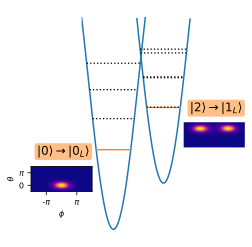

In [40]:
def V(theta, phi):
    phiext = 0.
    return (-2*EJ * np.cos(theta) * np.cos(phi - np.pi * phiext) + EL* phi**2 + 2*EJ)
theta_1 = np.linspace(-2, 2, num=50)
theta_2 = np.linspace(1.47, 6.28-1.47, num=50)
eval_zp = np.array([ 6.40836721,  8.91173084,  9.80996825,  9.83378077, 11.24434186,
       12.19997287, 12.2769947 , 13.37183189, 14.19848836, 14.50087939])

# double valley
fig, ax = plt.subplots(figsize=(2,4.2))
plt.plot(theta_1, V(theta_1, 0), color=colors[0])
plt.plot(theta_2, V(theta_2, np.pi), color=colors[0])
plt.xlim(-2,5)
valley = [0,0,1,1,0, 1,1,0,1,1]
for i, evals in enumerate(eval_zp):
    if valley[i] == 0:
        x0 = -np.arccos(-0.5*evals/EJ+1)
        if i == 0:
            plt.axhline(y=evals, xmin=(x0+2)/7, xmax=(-x0+2)/7, linestyle='-', linewidth=1.3, color=colors[1])
        else:
            plt.axhline(y=evals, xmin=(x0+2)/7, xmax=(-x0+2)/7, linestyle='dotted', linewidth=1.3, color='black')

    else:
        x0 = np.arccos(0.5*(evals - EL*np.pi**2 - 2*EJ) / EJ)
        if i == 2:
            plt.axhline(y=evals, xmin=(x0+2)/7, xmax=(2*np.pi-x0+2)/7, linestyle='-', linewidth=1.3, color=colors[1])
        else:
            plt.axhline(y=evals, xmin=(x0+2)/7, xmax=(2*np.pi-x0+2)/7, linestyle='dotted', linewidth=1.3, color='black')

# text
ax.text(-4.8, 6, r'$|0\rangle\to|0_L\rangle$', fontsize=12, color='black',
        bbox=dict(facecolor=colors[1], edgecolor='none', alpha=0.5, boxstyle="round,pad=0.2"))
ax.text(4.8, 9.5, r'$|2\rangle\to|1_L\rangle$', fontsize=12, color='black',
        bbox=dict(facecolor=colors[1], edgecolor='none', alpha=0.5, boxstyle="round,pad=0.2"))
ax.axis('off')
# plt.grid()
# ax.minorticks_on()  # Turn on minor ticks
# ax.grid(True, which='minor', linestyle=':', linewidth='0.5')  # Add minor grid lines

# wavefuction inset
ax1 = inset_axes(ax, width=0.85, height=0.35,
                    bbox_transform=ax.transAxes, # relative axes coordinates
                    bbox_to_anchor=(-0.49,0.19),    # relative axes coordinates
                    loc=3)
wf = zero_pi.wavefunction(esys=None, which=0, theta_grid=None)
[phi_min, theta_min] = wf.gridspec.min_vals
[phi_max, theta_max] = wf.gridspec.max_vals
ax1.imshow(np.abs(wf.amplitudes), extent=[phi_min, phi_max, theta_max, theta_min], aspect="auto", cmap='plasma')
ax1.set_xlim(-2*np.pi,2*np.pi)
ax1.set_xticks([-np.pi,np.pi],['-$\pi$','$\pi$'])
ax1.set_xlabel('$\phi$' )
ax1.set_yticks([0,np.pi],['0','$\pi$'])
ax1.invert_yaxis()
ax1.set_ylabel('$\\theta$');

ax1 = inset_axes(ax, width=0.85, height=0.35,
                    bbox_transform=ax.transAxes, # relative axes coordinates
                    bbox_to_anchor=(0.88,0.38),    # relative axes coordinates
                    loc=3)
wf = zero_pi.wavefunction(esys=None, which=2, theta_grid=None)
[phi_min, theta_min] = wf.gridspec.min_vals
[phi_max, theta_max] = wf.gridspec.max_vals
ax1.imshow(np.abs(wf.amplitudes), extent=[phi_min, phi_max, theta_max, theta_min], aspect="auto", cmap='plasma')
ax1.set_xlim(-2*np.pi,2*np.pi)
ax1.set_xticks([-np.pi,np.pi],['-$\pi$','$\pi$'])
ax1.set_xlabel('$\phi$' )
ax1.set_yticks([0,np.pi],['0','$\pi$'])
ax1.axis('off')
ax1.invert_yaxis()
ax1.set_ylabel('$\\theta$')
# plt.savefig('image/fig1c_double_valley.pdf', dpi=300, bbox_inches='tight')


## Transition freq

(14.5, 16.5)

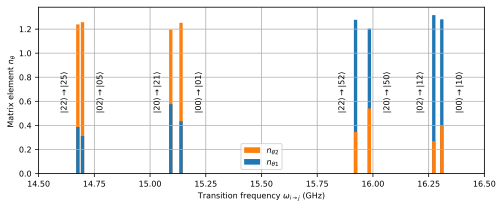

In [41]:
color1 = '#1f77b4'
color2 = '#ff7f0e'
transparency = 1
width = 0.015
fig, ax = plt.subplots(figsize = (8,3));
for i in range(len(w_ij)):


    if N_theta1[i] >  N_theta2[i]:
        plt.bar(w_ij[i], N_theta1[i], color=color1,  alpha=transparency, width=width)
        plt.bar(w_ij[i], N_theta2[i], color=color2, alpha=transparency, width=width)
    else:
        plt.bar(w_ij[i], N_theta2[i], color=color2, alpha=transparency, width=width)
        plt.bar(w_ij[i], N_theta1[i], color=color1,  alpha=transparency, width=width)
plt.bar(w_ij[-1], N_theta2[-1], color=color2, label='$n_{\\theta 2}$', alpha=transparency, width=width)
plt.bar(w_ij[-1], N_theta1[-1], color=color1, label='$n_{\\theta 1}$', alpha=transparency, width=width)

i = 3
plt.text(w_ij[i] - 0.06 , 0.5, r'$|22\rangle\to|25\rangle$', ha='center', va='bottom', rotation=90)
plt.text(w_ij[i+1] + 0.08 , 0.5, r'$|02\rangle\to|05\rangle$', ha='center', va='bottom', rotation=90)

plt.text(w_ij[i+2] - 0.06 , 0.5, r'$|20\rangle\to|21\rangle$', ha='center', va='bottom', rotation=90)
plt.text(w_ij[i+3] + 0.08 , 0.5, r'$|00\rangle\to|01\rangle$', ha='center', va='bottom', rotation=90)

plt.text(w_ij[i+4] - 0.06 , 0.5, r'$|22\rangle\to|52\rangle$', ha='center', va='bottom', rotation=90)
plt.text(w_ij[i+5] + 0.08 , 0.5, r'$|20\rangle\to|50\rangle$', ha='center', va='bottom', rotation=90)

plt.text(w_ij[i+6] - 0.06 , 0.5, r'$|02\rangle\to|12\rangle$', ha='center', va='bottom', rotation=90)
plt.text(w_ij[i+7] + 0.08 , 0.5, r'$|00\rangle\to|10\rangle$', ha='center', va='bottom', rotation=90)

plt.xlabel('Transition frequency $\omega_{i\\to j}$ (GHz)')
plt.ylabel('Matrix element $n_{\\theta}$ ')
plt.legend(loc='best')
plt.grid()
plt.xlim(14.5, 16.5)
# plt.savefig('cz_n_theta_vs_freq_1.png',dpi=300,bbox_inches='tight')

In [42]:
w_20_50 + 2*np.pi*(-0.04296367)

15.714051299913487

Text(0.5, 1.0, 'CZ dark $\\omega_d$')

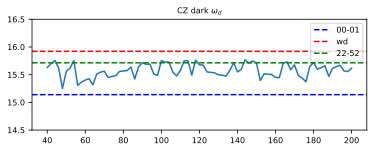

In [50]:
f_cz_dark = pd.read_csv("data_fig/data_cz_n1n2_20_dark.txt")
w_20_50 = 15.984
w_00_01 = 15.139
w_22_52 = 15.922
w_d = w_20_50 + 2*np.pi*f_cz_dark['detuning']
fig, ax = plt.subplots(figsize=(6, 2))
plt.plot(f_cz_dark['tg'], w_d)
plt.axhline(y=w_00_01 , color='b', linestyle='--', label='00-01')
plt.axhline(y=w_22_52 , color='r', linestyle='--', label='wd')
plt.axhline(y=w_20_50 + 2*np.pi*(-0.04296367) , color='g', linestyle='--', label='22-52')
plt.legend()
plt.ylim(14.5, 16.5)
plt.title(r'CZ dark $\omega_d$')

In [ ]:
w_20_50 + 2*np.pi*

Text(0.5, 1.0, 'CZ $\\omega_d$')

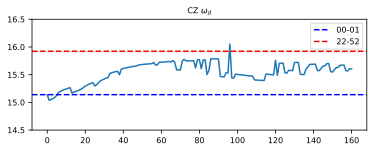

In [44]:
f_cz = pd.read_csv("data_fig/data_cz_n2_20.txt").to_numpy()
w_20_50 = 15.984
w_d = w_20_50 + 2*np.pi*f_cz[:,3]
fig, ax = plt.subplots(figsize=(6, 2))
plt.plot(w_d)
plt.axhline(y=w_00_01 , color='b', linestyle='--', label='00-01')
plt.axhline(y=w_22_52 , color='r', linestyle='--', label='22-52')
plt.legend()
plt.ylim(14.5, 16.5)
plt.title(r'CZ $\omega_d$')

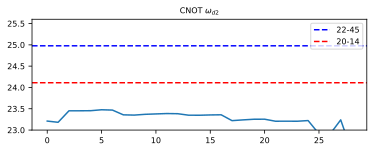

In [46]:
f_cnot = pd.read_csv("data_fig/data_cnot_45_2A.txt").to_numpy()
w_02_45 = 46.771
w_22_45 = 24.977
w_20_14 = 24.111
w_00_14 = 45.905
w_d1 = w_02_45 + 2*np.pi*f_cnot[:,5]
w_d2 = w_22_45 + 2*np.pi*f_cnot[:,6]
fig, ax = plt.subplots(figsize=(6, 2))
plt.plot(w_d2)
plt.axhline(y=w_22_45 , color='b', linestyle='--', label='22-45')
plt.axhline(y=w_20_14 , color='r', linestyle='--', label='20-14')
plt.legend()
plt.ylim(23., 25.6)
plt.title(r'CNOT $\omega_{d2}$')
plt.legend()

Text(0.5, 1.0, 'CNOT $\\omega_{d1}$')

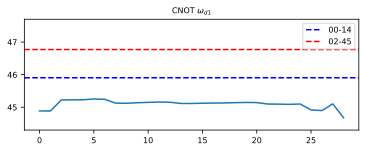

In [44]:
fig, ax = plt.subplots(figsize=(6, 2))
plt.plot(w_d1)
plt.axhline(y=w_00_14 , color='b', linestyle='--', label='00-14')
plt.axhline(y=w_02_45 , color='r', linestyle='--', label='02-45')
plt.legend()
plt.ylim(44.3, 47.7)
plt.title(r'CNOT $\omega_{d1}$')

In [ ]:
=

[(0.0, 0.08), (0.0, 0.08)]

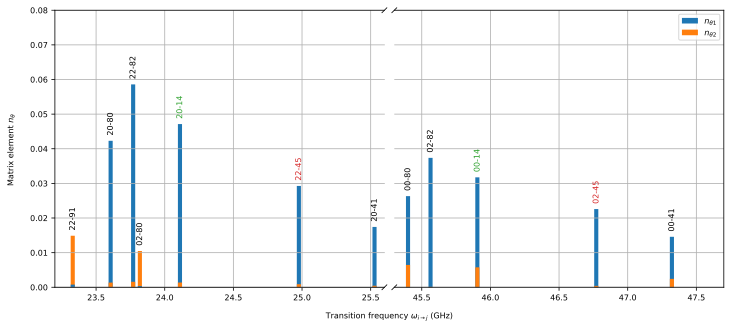

In [49]:
color1 = '#1f77b4'
color2 = '#ff7f0e'
transparency = 1
width = 0.03
xlims=( (23.2, 25.6), (45.3, 47.7))
# xlims=((14.05, 16.5), (21.1, 21.50), (23.2, 25.6), (45.3, 47.7))
fig = plt.figure(figsize=(12, 5))
bax = brokenaxes(xlims=xlims, wspace=0.03, d=0.004, despine=False, hspace=0.05)

for i in range(len(w_ij)-1):
    if N_theta1[i] >  N_theta2[i]:
        bax.bar(w_ij[i], N_theta1[i], color=color1,  alpha=transparency, width=width)
        bax.bar(w_ij[i], N_theta2[i], color=color2, alpha=transparency, width=width)
    else:
        bax.bar(w_ij[i], N_theta2[i], color=color2, alpha=transparency, width=width)
        bax.bar(w_ij[i], N_theta1[i], color=color1,  alpha=transparency, width=width)
bax.bar(w_ij[-1], N_theta1[-1], color=color1, label='$n_{\\theta 1}$', alpha=transparency, width=width)
bax.bar(w_ij[-1], N_theta2[-1], color=color2, label='$n_{\\theta 2}$', alpha=transparency, width=width)

Green = '#2ca02c'
Red = '#d62728'

for i in range(len(w_ij)):
    for xlim in xlims:
        if xlim[0] < w_ij[i] <xlim[1]:
            if trans[i] in ['00-14', '20-14']:
                bax.text(w_ij[i], np.max([N_theta1[i], N_theta2[i]]) + 0.0015, trans[i],
                        ha='center', va='bottom', rotation=90, color=Green)
            elif trans[i] in ['02-45', '22-45']:
                bax.text(w_ij[i], np.max([N_theta1[i], N_theta2[i]]) + 0.0015, trans[i],
                        ha='center', va='bottom', rotation=90, color=Red)
            else:
                bax.text(w_ij[i], np.max([N_theta1[i], N_theta2[i]]) + 0.0015, trans[i],
                        ha='center', va='bottom', rotation=90)



bax.set_xlabel('Transition frequency $\omega_{i\\to j}$ (GHz)', labelpad=25)
bax.set_ylabel('Matrix element $n_{\\theta}$ ', labelpad=40)
bax.grid()
bax.legend()
bax.set_ylim(0, 0.08)
# plt.savefig('cnot_n_theta_vs_freq.png', dpi=300, bbox_inches='tight')

In [ ]:
=

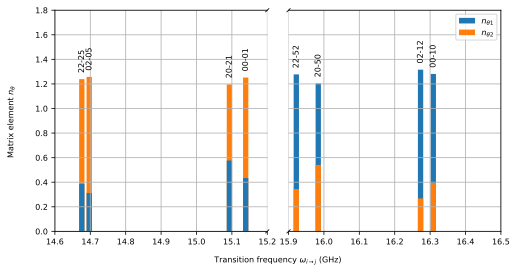

In [24]:
color1 = '#1f77b4'
color2 = '#ff7f0e'
transparency = 1
width = 0.015
xlims=( (14.6, 15.2), (15.9, 16.5))
fig = plt.figure(figsize=(8, 4))
bax = brokenaxes(xlims=xlims, wspace=0.1, d=0.004, despine=False, hspace=0.05)

for i in range(len(w_ij)-1):
    if N_theta1[i] >  N_theta2[i]:
        bax.bar(w_ij[i], N_theta1[i], color=color1,  alpha=transparency, width=width)
        bax.bar(w_ij[i], N_theta2[i], color=color2, alpha=transparency, width=width)
    else:
        bax.bar(w_ij[i], N_theta2[i], color=color2, alpha=transparency, width=width)
        bax.bar(w_ij[i], N_theta1[i], color=color1,  alpha=transparency, width=width)
bax.bar(w_ij[-1], N_theta1[-1], color=color1, label='$n_{\\theta 1}$', alpha=transparency, width=width)
bax.bar(w_ij[-1], N_theta2[-1], color=color2, label='$n_{\\theta 2}$', alpha=transparency, width=width)

for i in range(len(w_ij)):
    for xlim in xlims:
        if xlim[0] < w_ij[i] <xlim[1]:
            bax.text(w_ij[i], np.max([N_theta1[i], N_theta2[i]]) + 0.05, trans[i],  ha='center', va='bottom', rotation=90)

bax.set_xlabel('Transition frequency $\omega_{i\\to j}$ (GHz)', labelpad=25)
bax.set_ylabel('Matrix element $n_{\\theta}$ ', labelpad=40)
bax.grid()
bax.legend(loc='best')
bax.set_ylim(0, 1.8);

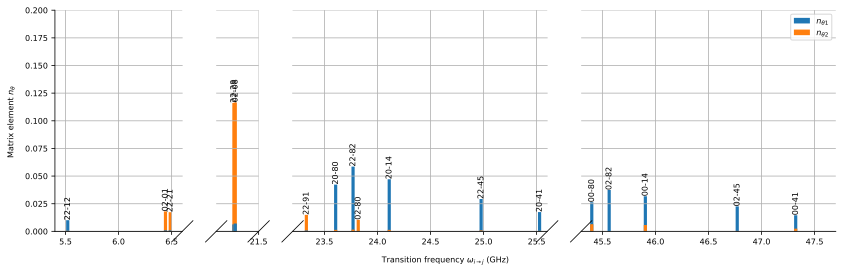

In [25]:
color1 = '#1f77b4'
color2 = '#ff7f0e'
transparency = 1
width = 0.03
# xlims=( (23.2, 25.6), (45.3, 47.7))
xlims=((5.4, 6.60), (21.1, 21.50), (23.2, 25.6), (45.3, 47.7))
fig = plt.figure(figsize=(14, 4))
bax = brokenaxes(xlims=xlims, hspace=.05)

for i in range(len(w_ij)-1):
    if N_theta1[i] >  N_theta2[i]:
        bax.bar(w_ij[i], N_theta1[i], color=color1,  alpha=transparency, width=width)
        bax.bar(w_ij[i], N_theta2[i], color=color2, alpha=transparency, width=width)
    else:
        bax.bar(w_ij[i], N_theta2[i], color=color2, alpha=transparency, width=width)
        bax.bar(w_ij[i], N_theta1[i], color=color1,  alpha=transparency, width=width)
bax.bar(w_ij[-1], N_theta1[-1], color=color1, label='$n_{\\theta 1}$', alpha=transparency, width=width)
bax.bar(w_ij[-1], N_theta2[-1], color=color2, label='$n_{\\theta 2}$', alpha=transparency, width=width)

for i in range(len(w_ij)):
    for xlim in xlims:
        if xlim[0] < w_ij[i] <xlim[1]:
            bax.text(w_ij[i], np.max([N_theta1[i], N_theta2[i]]), trans[i],  ha='center', va='bottom', rotation=90)

bax.set_xlabel('Transition frequency $\omega_{i\\to j}$ (GHz)', labelpad=25)
bax.set_ylabel('Matrix element $n_{\\theta}$ ', labelpad=40)
bax.grid()
bax.legend()
bax.set_ylim(0, 0.2);

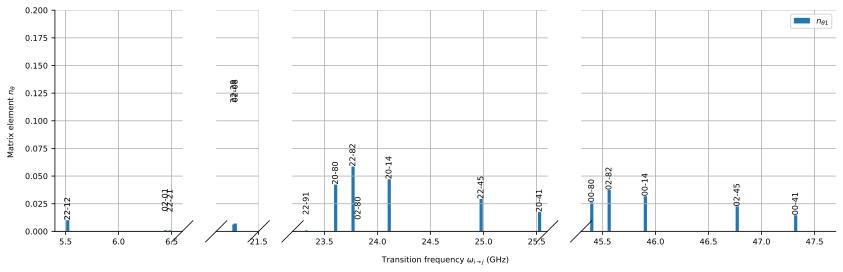

In [26]:
color1 = '#1f77b4'
color2 = '#ff7f0e'
transparency = 1
width = 0.03
# xlims=( (23.2, 25.6), (45.3, 47.7))
xlims=((5.4, 6.60), (21.1, 21.50), (23.2, 25.6), (45.3, 47.7))
fig = plt.figure(figsize=(14, 4))
bax = brokenaxes(xlims=xlims, hspace=.05)
bax.bar(w_ij, N_theta1, color=color1, label='$n_{\\theta 1}$', alpha=transparency, width=width)

for i in range(len(w_ij)):
    for xlim in xlims:
        if xlim[0] < w_ij[i] <xlim[1]:
            bax.text(w_ij[i], np.max([N_theta1[i], N_theta2[i]]), trans[i],  ha='center', va='bottom', rotation=90)

bax.set_xlabel('Transition frequency $\omega_{i\\to j}$ (GHz)', labelpad=25)
bax.set_ylabel('Matrix element $n_{\\theta}$ ', labelpad=40)
bax.grid()
bax.legend()
bax.set_ylim(0, 0.2);

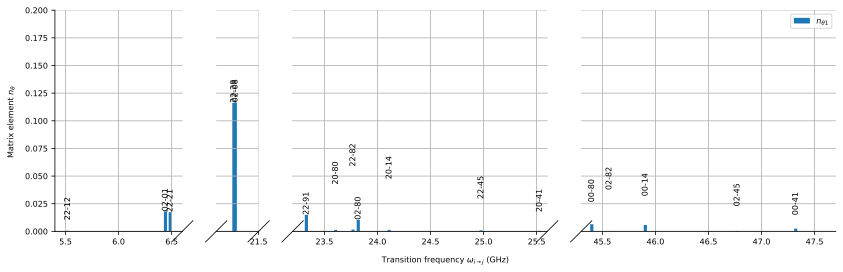

In [27]:
color1 = '#1f77b4'
color2 = '#ff7f0e'
transparency = 1
width = 0.03
# xlims=( (23.2, 25.6), (45.3, 47.7))
xlims=((5.4, 6.60), (21.1, 21.50), (23.2, 25.6), (45.3, 47.7))
fig = plt.figure(figsize=(14, 4))
bax = brokenaxes(xlims=xlims, hspace=.05)
bax.bar(w_ij, N_theta2, color=color1, label='$n_{\\theta 1}$', alpha=transparency, width=width)

for i in range(len(w_ij)):
    for xlim in xlims:
        if xlim[0] < w_ij[i] <xlim[1]:
            bax.text(w_ij[i], np.max([N_theta1[i], N_theta2[i]]), trans[i],  ha='center', va='bottom', rotation=90)

bax.set_xlabel('Transition frequency $\omega_{i\\to j}$ (GHz)', labelpad=25)
bax.set_ylabel('Matrix element $n_{\\theta}$ ', labelpad=40)
bax.grid()
bax.legend()
bax.set_ylim(0, 0.2);

## Matrix element

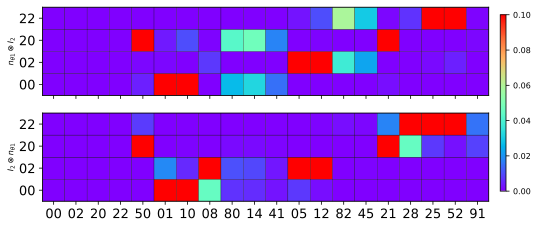

In [28]:
vmax = 0.1
fig, ax = plt.subplots(figsize=(8, 3.5), nrows=2)

mat = n_theta1_truc.full()[:4,:]
cbar = ax[0].pcolor(np.abs(mat), edgecolors='k', cmap='rainbow', vmax=vmax)
mat2 = n_theta2_truc.full()[:4,:]
ax[1].pcolor(np.abs(mat2), edgecolors='k', cmap='rainbow', vmax=vmax)

for i in range(2):
    ax[i].set_xticks(np.arange(0.5, mat.shape[1], 1))
    ax[i].set_yticks(np.arange(0.5, mat.shape[0], 1))
    ax[i].set_yticklabels(trunc_states[: mat.shape[0]], fontsize=13)  # Set fontsize for yticks
ax[0].set_xticklabels(labels='')  # Set fontsize for xticks
ax[1].set_xticklabels(trunc_states, fontsize=13)  # Set fontsize for xticks
ax[0].set_ylabel(r'$n_{\theta 1} \otimes I_2$')
ax[1].set_ylabel(r'$I_2 \otimes n_{\theta 1}$')
# cbar_ax =   # [left, bottom, width, height]
fig.colorbar(cbar, cax=fig.add_axes([0.92, 0.15, 0.01, 0.7]))
# plt.savefig('cnot_n_theta.png', dpi=300, bbox_inches='tight')

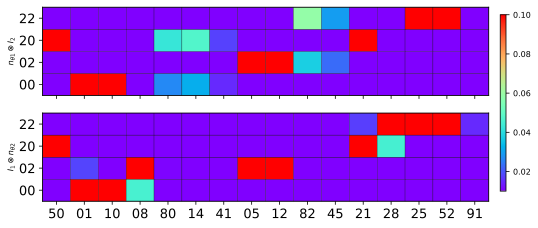

In [29]:
vmin = 0.01
vmax = 0.1
fig, ax = plt.subplots(figsize=(8, 3.5), nrows=2)

mat = n_theta1_truc.full()[:4,4:]
cbar = ax[0].pcolor(np.abs(mat), edgecolors='k', cmap='rainbow', vmax=vmax, vmin=vmin)
mat2 = n_theta2_truc.full()[:4,4:]
ax[1].pcolor(np.abs(mat2), edgecolors='k', cmap='rainbow', vmax=vmax, vmin=vmin)

for i in range(2):
    ax[i].set_xticks(np.arange(0.5, mat.shape[1], 1))
    ax[i].set_yticks(np.arange(0.5, mat.shape[0], 1))
    ax[i].set_yticklabels(trunc_states[: mat.shape[0]], fontsize=13)  # Set fontsize for yticks
ax[0].set_xticklabels(labels='')  # Set fontsize for xticks
ax[1].set_xticklabels(trunc_states[4:], fontsize=13)  # Set fontsize for xticks
ax[0].set_ylabel(r'$n_{\theta 1} \otimes I_2$')
ax[1].set_ylabel(r'$I_1 \otimes n_{\theta 2}$')
# cbar_ax =   # [left, bottom, width, height]
fig.colorbar(cbar, cax=fig.add_axes([0.92, 0.15, 0.01, 0.7]))
# plt.savefig('cnot_n_theta.png', dpi=300, bbox_inches='tight')

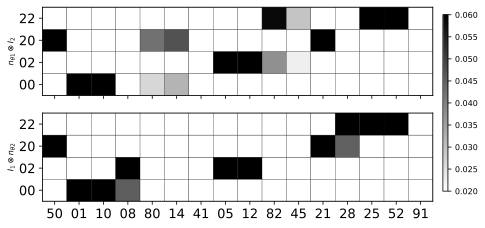

In [30]:
vmin = 0.02
vmax = 0.06
fig, ax = plt.subplots(figsize=(7, 3.5), nrows=2)
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('mycmap', ['white', 'black'])

mat = n_theta1_truc.full()[:4,4:]
cbar = ax[0].pcolor(np.abs(mat), edgecolors='k', cmap=cmap, vmax=vmax, vmin=vmin)
mat2 = n_theta2_truc.full()[:4,4:]
ax[1].pcolor(np.abs(mat2), edgecolors='k', cmap=cmap, vmax=vmax, vmin=vmin)

for i in range(2):
    ax[i].set_xticks(np.arange(0.5, mat.shape[1], 1))
    ax[i].set_yticks(np.arange(0.5, mat.shape[0], 1))
    ax[i].set_yticklabels(trunc_states[: mat.shape[0]], fontsize=13)  # Set fontsize for yticks
ax[0].set_xticklabels(labels='')  # Set fontsize for xticks
ax[1].set_xticklabels(trunc_states[4:], fontsize=13)  # Set fontsize for xticks
ax[0].set_ylabel(r'$n_{\theta 1} \otimes I_2$')
ax[1].set_ylabel(r'$I_1 \otimes n_{\theta 2}$')
# cbar_ax =   # [left, bottom, width, height]
fig.colorbar(cbar, cax=fig.add_axes([0.92, 0.15, 0.01, 0.7]))
# plt.savefig('cnot_n_theta.png', dpi=300, bbox_inches='tight')

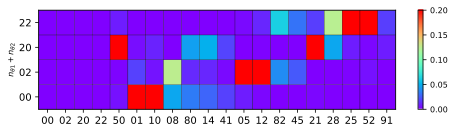

In [31]:
vmax = 0.2
mat = n_theta1_truc.full()[:4,:] + n_theta2_truc.full()[:4,:]
fig, ax = plt.subplots(figsize=(8, 1.8))
plt.pcolor(np.abs(mat), edgecolors='k', cmap='rainbow', vmax=vmax)
dim_plot = mat.shape[0]
ax.set_xticks(np.arange(0.5, mat.shape[1], 1))
ax.set_yticks(np.arange(0.5, mat.shape[0], 1))
ax.set_xticklabels(trunc_states[: mat.shape[1]], fontsize=10)  # Set fontsize for xticks
ax.set_yticklabels(trunc_states[: mat.shape[0]], fontsize=10)  # Set fontsize for yticks
plt.ylabel(r'$n_{\theta 1} + n_{\theta 2}$')
plt.colorbar();

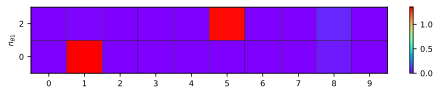

In [32]:
mat = np.abs(np.array([ n_theta1[0,:], n_theta1[2,:] ]))
vmax = np.max(mat)
fig, ax = plt.subplots(figsize=(8, 1.2))
plt.pcolor(mat, edgecolors='k', cmap='rainbow', vmax=vmax)
ax.set_xticks(np.arange(0.5, mat.shape[1], 1), np.arange(0, mat.shape[1]))
ax.set_yticks(np.arange(0.5, mat.shape[0], 1), [0,2])
plt.ylabel(r'$n_{\theta 1}$')
plt.colorbar();

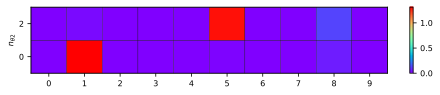

In [33]:
mat = np.abs(np.array([ n_theta2[0,:], n_theta2[2,:] ]))
vmax = np.max(mat)
fig, ax = plt.subplots(figsize=(8, 1.2))
plt.pcolor(mat, edgecolors='k', cmap='rainbow', vmax=vmax)
ax.set_xticks(np.arange(0.5, mat.shape[1], 1), np.arange(0, mat.shape[1]))
ax.set_yticks(np.arange(0.5, mat.shape[0], 1), [0,2])
plt.ylabel(r'$n_{\theta 2}$')
plt.colorbar();

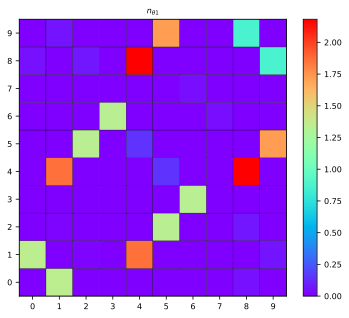

In [34]:
mat = n_theta1
fig, ax = plt.subplots(figsize=(6, 5))
plt.pcolor(np.abs(mat), edgecolors='k', cmap='rainbow')
dim_plot = mat.shape[0]
ax.set_xticks(np.arange(0.5, dim_plot, 1), np.arange(0, dim_plot))
ax.set_yticks(np.arange(0.5, dim_plot, 1), np.arange(0, dim_plot))
plt.title(r'$n_{\theta 1}$')
plt.colorbar();

In [35]:
n1n2 = np.kron(n_theta1, n_theta2)
mat = n1n2
fig, ax = plt.subplots(figsize=(10, 8))
plt.pcolor(np.abs(mat), edgecolors='k', cmap='rainbow')
plt.title(r'$n_{\theta 1} \otimes n_{\theta 2}$')
plt.colorbar();

In [36]:
plt.figure(figsize =(10, 8))
plt.pcolor(np.abs(N_b_dress), edgecolors='k', cmap='rainbow')
plt.title(r'$I_1 \otimes n_{\theta 2}$')
plt.colorbar();

NameError: name 'N_b_dress' is not defined

<Figure size 1000x800 with 0 Axes>

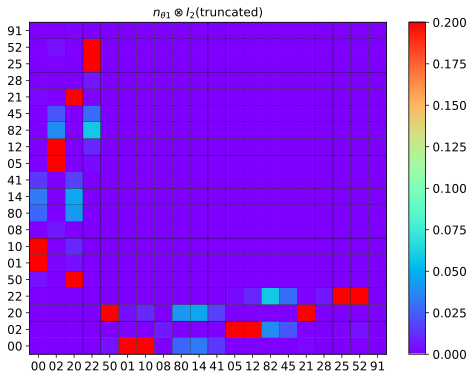

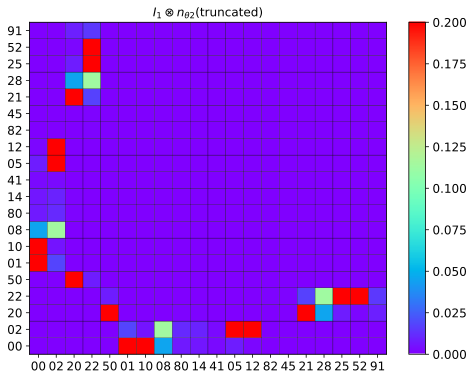

In [ ]:
vmax = 0.2
mat = N_a_trunc.full()
fig, ax = plt.subplots(figsize=(8, 6))
plt.pcolor(np.abs(mat), edgecolors='k', cmap='rainbow', vmax=vmax)
dim_plot = mat.shape[0]
ax.set_xticks(np.arange(0.5, dim_plot, 1), trunc_states)
ax.set_yticks(np.arange(0.5, dim_plot, 1), trunc_states)
plt.title(r'$n_{\theta 1} \otimes I_2$(truncated)')
plt.colorbar();

mat = N_b_trunc.full()
fig, ax = plt.subplots(figsize=(8, 6))
plt.pcolor(np.abs(mat), edgecolors='k', cmap='rainbow', vmax=vmax)
dim_plot = mat.shape[0]
ax.set_xticks(np.arange(0.5, dim_plot, 1), trunc_states)
ax.set_yticks(np.arange(0.5, dim_plot, 1), trunc_states)
plt.title(r'$I_1 \otimes n_{\theta 2}$(truncated)')
plt.colorbar();

## Get transitions

In [ ]:
print(order_sort.index('52'))
for i in logi_space:
    idx = order_sort.index(i)
    print(eval_tot[idx])

45
0.0
3.409968431459745
3.4434144469394896
6.85338261892412
